In [1]:
# --- Célula 1: Mudar Diretório ---
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
import torchtuples as tt
from pycox.models import LogisticHazard
from pycox.evaluation import EvalSurv
from sklearn.model_selection import train_test_split


# Agora o diretório de trabalho é a pasta raiz. A importação absoluta funciona diretamente.
from processamento import PassandoDados # biblioteca local
from funcaolog import get_callbacks, SaveFullModelCallback # biblioteca local

print("Importação bem-sucedida!")

Importação bem-sucedida!


In [9]:
import pandas as pd
import numpy as np
import scipy.integrate
from lifelines import KaplanMeierFitter

# Função auxiliar (sem alterações)
def get_censoring_probabilities(events, durations):
    kmf_cens = KaplanMeierFitter()
    kmf_cens.fit(durations, event_observed=(1 - events))
    return kmf_cens

def manual_integrated_brier_score(survival_prediction_df, durations, events, time_grid):
    """
    Calcula o Integrated Brier Score (IBS) manualmente.
    VERSÃO CORRIGIDA.
    """
    kmf_cens = get_censoring_probabilities(events, durations)

    brier_scores = []
    for t in time_grid:
        pos = survival_prediction_df.index.searchsorted(t, side='right')
        
        if pos == 0:
            preds_at_t = pd.Series(1.0, index=survival_prediction_df.columns)
        else:
            preds_at_t = survival_prediction_df.iloc[pos - 1]

        # A previsão agora é chamada sem o argumento extra
        g_t = kmf_cens.predict(t) # <-- MUDANÇA AQUI
        if g_t == 0: g_t = 1e-10

        weighted_errors = []
        for i in range(len(durations)):
            T_i, delta_i = durations[i], events[i]
            pred_i = preds_at_t.iloc[i]

            # A previsão agora é chamada sem o argumento extra
            g_ti = kmf_cens.predict(T_i) # <-- MUDANÇA AQUI
            if g_ti == 0: g_ti = 1e-10

            if delta_i == 1 and T_i <= t:
                error = (0 - pred_i)**2 / g_ti
                weighted_errors.append(error)
            elif T_i > t:
                error = (1 - pred_i)**2 / g_t
                weighted_errors.append(error)

        if len(weighted_errors) > 0:
            brier_scores.append(np.mean(weighted_errors))
        else:
            brier_scores.append(0)

    integral = scipy.integrate.simpson(brier_scores, time_grid)
    return integral / (time_grid[-1] - time_grid[0])

def manual_integrated_nbll(survival_prediction_df, durations, events, time_grid):
    """
    Calcula o Integrated Negative Binomial Log-Likelihood (INBLL) manualmente.
    VERSÃO CORRIGIDA.
    """
    kmf_cens = get_censoring_probabilities(events, durations)

    nbll_scores = []
    for t in time_grid:
        pos = survival_prediction_df.index.searchsorted(t, side='right')

        if pos == 0:
            preds_at_t = pd.Series(1.0 - 1e-10, index=survival_prediction_df.columns)
        else:
            preds_at_t = survival_prediction_df.iloc[pos - 1]

        # A previsão agora é chamada sem o argumento extra
        g_t = kmf_cens.predict(t) # <-- MUDANÇA AQUI
        if g_t == 0: g_t = 1e-10

        weighted_log_likelihoods = []
        for i in range(len(durations)):
            T_i, delta_i = durations[i], events[i]
            pred_i = max(min(preds_at_t.iloc[i], 1 - 1e-10), 1e-10)
            
            # A previsão agora é chamada sem o argumento extra
            g_ti = kmf_cens.predict(T_i) # <-- MUDANÇA AQUI
            if g_ti == 0: g_ti = 1e-10

            if delta_i == 1 and T_i <= t:
                ll = np.log(1 - pred_i) / g_ti
                weighted_log_likelihoods.append(ll)
            elif T_i > t:
                ll = np.log(pred_i) / g_t
                weighted_log_likelihoods.append(ll)

        if len(weighted_log_likelihoods) > 0:
            nbll_scores.append(-np.mean(weighted_log_likelihoods))
        else:
            nbll_scores.append(0)

    integral = scipy.integrate.simpson(nbll_scores, time_grid)
    return integral / (time_grid[-1] - time_grid[0])

# TESTE COM AMOSTRA

Processando pacientes: 100%|██████████| 756/756 [00:11<00:00, 64.44paciente/s] 
INFO:Processamento:Processado paciente P1066, épocas processadas: 60, tempo: 1387 dias, evento: 0


Limite de features: 12000, Limite de labels: None, Método: neurokit
0:	[2s / 2s],		train_loss: 11.0291,	val_loss: 10.0296
1:	[2s / 5s],		train_loss: 10.9174,	val_loss: 9.9120
2:	[2s / 8s],		train_loss: 10.7594,	val_loss: 9.7724
3:	[3s / 11s],		train_loss: 10.5770,	val_loss: 9.5970
4:	[3s / 14s],		train_loss: 10.3722,	val_loss: 9.3713
5:	[3s / 18s],		train_loss: 10.0618,	val_loss: 9.0788
6:	[3s / 21s],		train_loss: 9.7109,	val_loss: 8.7009
7:	[3s / 24s],		train_loss: 9.2479,	val_loss: 8.2130
8:	[2s / 27s],		train_loss: 8.6411,	val_loss: 7.5927
9:	[2s / 30s],		train_loss: 7.8577,	val_loss: 6.8368
10:	[2s / 32s],		train_loss: 6.9465,	val_loss: 5.9745
11:	[2s / 34s],		train_loss: 5.9322,	val_loss: 5.0552
12:	[2s / 37s],		train_loss: 4.8822,	val_loss: 4.1471
13:	[2s / 40s],		train_loss: 3.8708,	val_loss: 3.3350
14:	[2s / 43s],		train_loss: 2.9902,	val_loss: 2.6774
15:	[2s / 46s],		train_loss: 2.2911,	val_loss: 2.2029
16:	[2s / 48s],		train_loss: 1.7818,	val_loss: 1.8953
17:	[2s / 51s],		tra

c:\Users\danie\anaconda3\envs\regressao_cox\Lib\site-packages\torchtuples\base.py:669: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.net.load_state_dict(torch.load(path

   ✅ Modelo final salvo em: D:\cox-models-sudden-death\Arquitetura\logs\checkpoints\TESTEnet1d_model1minlimpo.pth


Registered model 'TESTEnet1d_model1minlimpo' already exists. Creating a new version of this model...
2025/10/06 19:03:39 WARNING mlflow.tracking._model_registry.fluent: Run with id d1aac32d3b314397a50164cbfaf87b73 has no artifacts at artifact path 'TESTEnet1d_model1minlimpo', registering model based on models:/m-3a7fb51f64ed4d71a0eb6616cff9e75f instead
Created version '11' of model 'TESTEnet1d_model1minlimpo'.


✅ Treinamento e log concluídos no MLflow!
--- Plot da Perda de Treinamento e Validação ---


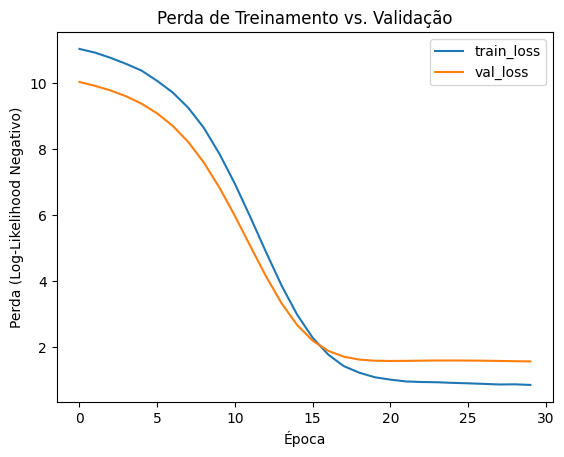

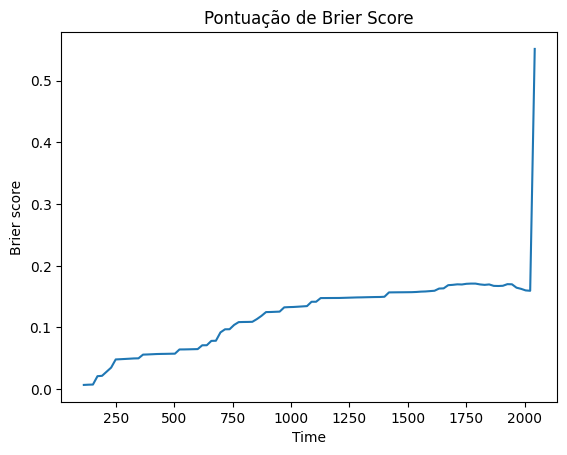

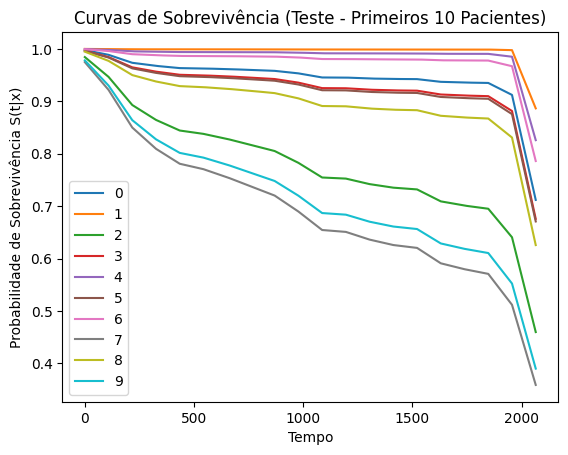

C-index (time-dependent): 0.3941
Integrated Brier Score: 0.15757222203097798
Integrated NLL: 0.7262


In [3]:
from processamento_amostra import PassandoDadosAmostra # biblioteca local
from funcaolog  import get_callbacks # biblioteca local
from metrica_grafico import manual_integrated_nbll, manual_integrated_brier_score # biblioteca local
 

import mlflow
import mlflow.pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchtuples as tt
from pycox.models import LogisticHazard
import matplotlib.pyplot as plt
from pycox.evaluation import EvalSurv
import torchtuples as tt
import os
import numpy as np




tensores = PassandoDadosAmostra(limite_features=12000,  metodo='neurokit')

dl_treino, dl_teste = tensores.convert_to_tensors()

tempos_teste_np, eventos_teste_np = tensores.get_evento_tempo()
amostra_mlflow = tensores.get_amostra_sinal()
labtrans = tensores.get_labtrans()

modelo = "TESTEnet1d_model1minlimpo"



# ============================================
# 1. ARQUITETURA CNN 1D
# ============================================
class Net1D(nn.Module):
    def __init__(self, out_features):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=3, out_channels=16, kernel_size=5, stride=1)
        self.max_pool = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(16, 16, 5, 1)
        self.glob_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(16, 16)
        self.fc2 = nn.Linear(16, out_features)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.max_pool(x)
        x = F.relu(self.conv2(x))
        x = self.glob_avg_pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# ============================================
# 2. INICIANDO EXPERIMENTO MLflow
# ============================================

mlflow.set_tracking_uri("file:///D:/cox-models-sudden-death/Arquitetura/logs/mlruns")
mlflow.set_experiment("TESTEecg_cox_experiment")

args = {'lr': 1e-3, 'weight_decay':1e-7}

with mlflow.start_run(run_name="TESTENet1D Cox Model1minlimpov2"):
    # -------------------
    # 2.1 Modelo
    # -------------------
    net_1d = Net1D(labtrans.out_features)
    
    optimizer = tt.optim.Adam(args['lr'])
    model = LogisticHazard(net_1d, optimizer, duration_index=labtrans.cuts)

    # -------------------
    # 2.2 Callbacks
    # -------------------
    
    #save_cb = SaveFullModelCallback(nome_modelo=modelo, save_each="epoch")
    #early_cb = get_callbacks()
    #callbacks = [early_cb, save_cb]
    callbacks = [get_callbacks()]

    # -------------------
    # 2.3 Treinamento
    # -------------------
    epochs = 30
    log = model.fit_dataloader(dl_treino, epochs, callbacks, True, val_dataloader=dl_teste)

    # -------------------
    # 2.4 Logando métricas no MLflow
    # -------------------
    df_log = log.to_pandas()

    for epoch, row in df_log.iterrows():
        mlflow.log_metric("train_loss", row["train_loss"], step=epoch)
        mlflow.log_metric("val_loss", row["val_loss"], step=epoch)

    #        # Definir o diretório para salvar o modelo
    save_dir = r"D:\cox-models-sudden-death\Arquitetura\logs\checkpoints"  # Diretório desejado (relativo ou absoluto)
    os.makedirs(save_dir, exist_ok=True) # Criar o diretório se ele não existir
    
    
    mlflow.pytorch.log_model(model.net, modelo) # Salvar modelo final no MLflow
    model_path = os.path.join(save_dir, f"{modelo}.pth") # Salvar o state_dict do modelo no diretório especificado
    torch.save(model.net.state_dict(), model_path)
    print(f"   ✅ Modelo final salvo em: {model_path}")
    
    #example = sinais[:1].numpy()  # pega 1 amostra real
    mlflow.pytorch.log_model(net_1d, modelo, input_example=amostra_mlflow)
    
    
    # 2. Registrar no MLflow Model Registry
    mlflow.register_model(
    f"runs:/{mlflow.active_run().info.run_id}/{modelo}",  # o mesmo nome que passou no log_model
    name=modelo)

    
    # -------------------
    # 2.6 Salvando hiperparâmetros
    # -------------------
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("learning_rate", args['lr'])
    mlflow.log_param("batch_size", dl_treino.batch_size)

    # -------------------
    # 2.7 Salvando artefatos (logs/checkpoints)
    # -------------------
    mlflow.log_artifact(fr"D:\cox-models-sudden-death\Arquitetura\logs\checkpoints\{modelo}.pth")
    mlflow.log_artifact(r"D:\cox-models-sudden-death\Arquitetura\logs\processamento_dados.log")

    print("✅ Treinamento e log concluídos no MLflow!")
    
    #=======================GRÁFICOS============================================
    # Diretório para salvar imagens localmente
    
    figures_dir = r"D:\cox-models-sudden-death\Arquitetura\logs\figuras"
    os.makedirs(figures_dir, exist_ok=True)
    
    # --- Plot da perda ---
    print("--- Plot da Perda de Treinamento e Validação ---")
    _ = log.plot()
    plt.title("Perda de Treinamento vs. Validação")
    plt.ylabel('Perda (Log-Likelihood Negativo)')
    plt.xlabel('Época')
    figura_perda_path = os.path.join(figures_dir, "perda_treino_val.png")
    plt.savefig(figura_perda_path)
    plt.show()
    # Log da figura no MLflow
    mlflow.log_artifact(figura_perda_path)

    # --- Avaliação no conjunto de teste ---
    dl_teste_x = tt.data.dataloader_input_only(dl_teste)
    curvas_sobrevida = model.interpolate(10).predict_surv_df(dl_teste_x)
    ev = EvalSurv(curvas_sobrevida, tempos_teste_np, eventos_teste_np, censor_surv='km')
      
    # Pontuação de Brier Score
    time_grid = np.linspace(tempos_teste_np.min(), tempos_teste_np.max(), 100)
    ev.brier_score(time_grid).plot()
    plt.title("Pontuação de Brier Score")
    plt.ylabel('Brier score')
    brier_path = os.path.join(figures_dir, "Brier_Score.png")
    plt.savefig(brier_path)
    _ = plt.xlabel('Time')
    # Log da figura no MLflow
    mlflow.log_artifact(brier_path)


    # --- Plot das curvas de sobrevivência ---
    curvas_sobrevida.iloc[:, :10].plot()
    plt.ylabel('Probabilidade de Sobrevivência S(t|x)')
    plt.xlabel('Tempo')
    plt.title("Curvas de Sobrevivência (Teste - Primeiros 10 Pacientes)")
    curvas_path = os.path.join(figures_dir, "curvas_sobrevida.png")
    plt.savefig(curvas_path)
    plt.show()
    # Log da figura no MLflow
    mlflow.log_artifact(curvas_path)
    
    #=======================MÉTRICAS============================================
    
    # C-index
    c_index = ev.concordance_td()
    print(f"C-index (time-dependent): {c_index:.4f}")
    mlflow.log_metric("c_index", c_index)    
    
    # # # Integrated Brier Score
    # int_brier_score = ev.integrated_brier_score(time_grid)
    # print(f'Integrated Brier Score: {int_brier_score:.4f}')
    # mlflow.log_metric("integrated_brier_score", int_brier_score)
    

    # # Integrated Negative Binomial Log-Likelihood
    # int_nbll = ev.integrated_nbll(time_grid)
    # print(f'Integrated NLL: {int_nbll:.4f}')
    # mlflow.log_metric("integrated_nbll", int_nbll)
    
    # Integrated Brier Score (MANUAL)
    int_brier_score = manual_integrated_brier_score(curvas_sobrevida, tempos_teste_np, eventos_teste_np, time_grid)
    # print(f'Integrated Brier Score: {int_brier_score:.4f}')
    print(f'Integrated Brier Score: {int_brier_score}')
    mlflow.log_metric("integrated_brier_score", int_brier_score)

    # Integrated Negative Binomial Log-Likelihood (MANUAL)
    int_nbll = manual_integrated_nbll(curvas_sobrevida, tempos_teste_np, eventos_teste_np, time_grid)
    print(f'Integrated NLL: {int_nbll:.4f}')
    mlflow.log_metric("integrated_nbll", int_nbll)
    
    


Processando pacientes: 100%|██████████| 756/756 [00:08<00:00, 93.66paciente/s] 
INFO:Processamento:Processado paciente P1066, épocas processadas: 60, tempo: 1387 dias, evento: 0


Limite de features: 12000, Limite de labels: None, Método: neurokit
0:	[2s / 2s],		train_loss: 10.9433,	val_loss: 9.9810
1:	[2s / 4s],		train_loss: 10.7789,	val_loss: 9.8401
2:	[2s / 7s],		train_loss: 10.6357,	val_loss: 9.6806
3:	[2s / 9s],		train_loss: 10.4426,	val_loss: 9.4959
4:	[3s / 12s],		train_loss: 10.2018,	val_loss: 9.2734
5:	[2s / 15s],		train_loss: 9.9445,	val_loss: 8.9951
6:	[2s / 18s],		train_loss: 9.6055,	val_loss: 8.6566
7:	[2s / 20s],		train_loss: 9.2055,	val_loss: 8.2437
8:	[2s / 23s],		train_loss: 8.6924,	val_loss: 7.7420
9:	[2s / 25s],		train_loss: 8.0841,	val_loss: 7.1493
10:	[2s / 27s],		train_loss: 7.3943,	val_loss: 6.4702
11:	[2s / 29s],		train_loss: 6.5728,	val_loss: 5.7185
12:	[2s / 32s],		train_loss: 5.7327,	val_loss: 4.9358
13:	[2s / 34s],		train_loss: 4.8419,	val_loss: 4.1648
14:	[2s / 36s],		train_loss: 3.9914,	val_loss: 3.4574
15:	[2s / 39s],		train_loss: 3.2306,	val_loss: 2.8475
16:	[2s / 41s],		train_loss: 2.5897,	val_loss: 2.3583
17:	[2s / 44s],		train_

c:\Users\danie\anaconda3\envs\regressao_cox\Lib\site-packages\torchtuples\base.py:669: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.net.load_state_dict(torch.load(path

29:	[2s / 1m:15s],		train_loss: 0.8548,	val_loss: 1.3251


2025/10/06 19:51:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/10/06 19:51:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Modelo final salvo em: D:\cox-models-sudden-death\Arquitetura\logs\checkpoints\TESTEnet1d_model1minlimpo.pth


Registered model 'TESTEnet1d_model1minlimpo' already exists. Creating a new version of this model...
2025/10/06 19:51:31 WARNING mlflow.tracking._model_registry.fluent: Run with id 3ea5adfe535e4a8f97ee0b8618fc464f has no artifacts at artifact path 'TESTEnet1d_model1minlimpo', registering model based on models:/m-ec02b67f6d0e4cd0bbe0e4567e20bcf0 instead
Created version '12' of model 'TESTEnet1d_model1minlimpo'.


--- Plot da Perda de Treinamento e Validação ---


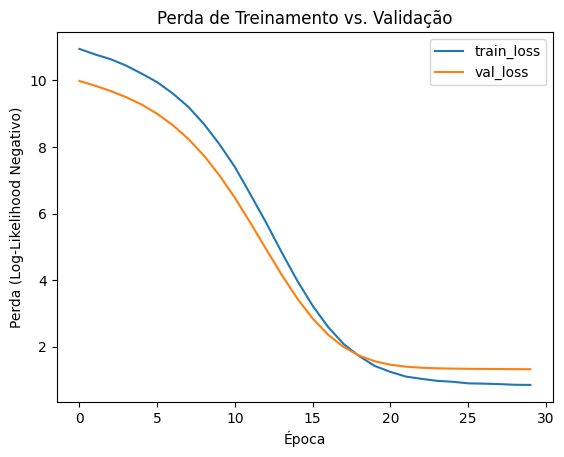

C-index (time-dependent): 0.3905
Integrated Brier Score: 0.15551758445038283
Integrated NLL: inf
✅ Treinamento e log concluídos no MLflow!


In [5]:
from processamento_amostra import PassandoDadosAmostra # biblioteca local
from funcaolog  import get_callbacks # biblioteca local
from metrica_grafico import manual_integrated_nbll, manual_integrated_brier_score # biblioteca local

import mlflow
import mlflow.pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchtuples as tt
from torchtuples.callbacks import Callback  # <--- IMPORTANTE
from pycox.models import LogisticHazard
import matplotlib.pyplot as plt
from pycox.evaluation import EvalSurv
import os
import numpy as np

# ============================================
# 0. Preparação dos dados
# ============================================
tensores = PassandoDadosAmostra(limite_features=12000, metodo='neurokit')
dl_treino, dl_teste = tensores.convert_to_tensors()
tempos_teste_np, eventos_teste_np = tensores.get_evento_tempo()
amostra_mlflow = tensores.get_amostra_sinal()
labtrans = tensores.get_labtrans()

modelo = "TESTEnet1d_model1minlimpo"

# ============================================
# 1. ARQUITETURA CNN 1D
# ============================================
class Net1D(nn.Module):
    def __init__(self, out_features):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=3, out_channels=16, kernel_size=5, stride=1)
        self.max_pool = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(16, 16, 5, 1)
        self.glob_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(16, 16)
        self.fc2 = nn.Linear(16, out_features)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.max_pool(x)
        x = F.relu(self.conv2(x))
        x = self.glob_avg_pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ============================================
# 2. CALLBACK para logar métricas no MLflow
# ============================================
class MLflowLogger(Callback):
    """Callback que loga métricas de treino e validação no MLflow a cada época."""
    def on_epoch_end(self):
        # Obtém a última linha do log (época atual)
        logs = self.model.log.to_pandas().iloc[-1]
        # A época atual é o tamanho do log menos 1
        current_epoch = len(self.model.log.to_pandas()) - 1
        # Loga métricas no MLflow
        mlflow.log_metric("train_loss", logs["train_loss"], step=current_epoch)
        mlflow.log_metric("val_loss", logs["val_loss"], step=current_epoch)


# ============================================
# 3. INICIANDO EXPERIMENTO MLflow
# ============================================
mlflow.set_tracking_uri("file:///D:/cox-models-sudden-death/Arquitetura/logs/mlruns")
mlflow.set_experiment("TESTEecg_cox_experiment")

args = {'lr': 1e-3, 'weight_decay': 1e-7}

with mlflow.start_run(run_name="TESTENet1D Cox Model1minlimpov2"):
    # -------------------
    # 3.1 Modelo
    # -------------------
    net_1d = Net1D(labtrans.out_features)
    optimizer = tt.optim.Adam(args['lr'])
    model = LogisticHazard(net_1d, optimizer, duration_index=labtrans.cuts)

    # -------------------
    # 3.2 Callbacks (inclui o MLflowLogger)
    # -------------------
    callbacks = [get_callbacks(), MLflowLogger()]

    # -------------------
    # 3.3 Treinamento
    # -------------------
    epochs = 30
    log = model.fit_dataloader(dl_treino, epochs, callbacks, True, val_dataloader=dl_teste)

    # -------------------
    # 3.4 Log e salvamento
    # -------------------
    df_log = log.to_pandas()

    save_dir = r"D:\cox-models-sudden-death\Arquitetura\logs\checkpoints"
    os.makedirs(save_dir, exist_ok=True)
    
    mlflow.pytorch.log_model(model.net, modelo)
    model_path = os.path.join(save_dir, f"{modelo}.pth")
    torch.save(model.net.state_dict(), model_path)
    print(f"✅ Modelo final salvo em: {model_path}")
    
    mlflow.pytorch.log_model(net_1d, modelo, input_example=amostra_mlflow)
    
    mlflow.register_model(
        f"runs:/{mlflow.active_run().info.run_id}/{modelo}",
        name=modelo
    )

    # -------------------
    # 3.5 Parâmetros e artefatos
    # -------------------
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("learning_rate", args['lr'])
    mlflow.log_param("batch_size", dl_treino.batch_size)

    mlflow.log_artifact(model_path)
    mlflow.log_artifact(r"D:\cox-models-sudden-death\Arquitetura\logs\processamento_dados.log")

    # -------------------
    # 3.6 Gráficos
    # -------------------
    figures_dir = r"D:\cox-models-sudden-death\Arquitetura\logs\figuras"
    os.makedirs(figures_dir, exist_ok=True)

    print("--- Plot da Perda de Treinamento e Validação ---")
    _ = log.plot()
    plt.title("Perda de Treinamento vs. Validação")
    plt.ylabel('Perda (Log-Likelihood Negativo)')
    plt.xlabel('Época')
    figura_perda_path = os.path.join(figures_dir, "perda_treino_val.png")
    plt.savefig(figura_perda_path)
    plt.show()
    mlflow.log_artifact(figura_perda_path)

    # --- Avaliação no conjunto de teste ---
    dl_teste_x = tt.data.dataloader_input_only(dl_teste)
    curvas_sobrevida = model.interpolate(10).predict_surv_df(dl_teste_x)
    ev = EvalSurv(curvas_sobrevida, tempos_teste_np, eventos_teste_np, censor_surv='km')

    # --- Métricas ---
    time_grid = np.linspace(tempos_teste_np.min(), tempos_teste_np.max(), 100)
    c_index = ev.concordance_td()
    mlflow.log_metric("c_index", c_index)
    print(f"C-index (time-dependent): {c_index:.4f}")

    int_brier_score = manual_integrated_brier_score(curvas_sobrevida, tempos_teste_np, eventos_teste_np, time_grid)
    mlflow.log_metric("integrated_brier_score", int_brier_score)
    print(f'Integrated Brier Score: {int_brier_score}')

    int_nbll = manual_integrated_nbll(curvas_sobrevida, tempos_teste_np, eventos_teste_np, time_grid)
    mlflow.log_metric("integrated_nbll", int_nbll)
    print(f'Integrated NLL: {int_nbll:.4f}')

    print("✅ Treinamento e log concluídos no MLflow!")


# MODELO - GERADOR DE AMOSTRA

In [ ]:
# treinamento.py

import mlflow
import mlflow.pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchtuples as tt
from pycox.models import LogisticHazard
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import numpy as np
import os

# Importa a classe do arquivo de processamento
from processamento import PassandoDados
# from funcaolog import get_callbacks # Esta importação não está sendo usada no código


modelo = "TESTEnet1d_model1minlimpo"

# ============================================
# 1. DEFINIÇÃO DA ARQUITETURA
# ============================================
class Net1D(nn.Module):
    def __init__(self, out_features):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=3, out_channels=16, kernel_size=5, stride=1)
        self.max_pool = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(16, 16, 5, 1)
        self.glob_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(16, 16)
        self.fc2 = nn.Linear(16, out_features)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.max_pool(x)
        x = F.relu(self.conv2(x))
        x = self.glob_avg_pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ============================================
# FUNÇÃO AUXILIAR DE AVALIAÇÃO
# ============================================
def evaluate_c_index(model, processor, generators, batch_size):
    """Calcula o C-index no conjunto de teste completo."""
    model.net.eval()
    
    # Coletar todos os dados de teste
    test_gen = processor.ecg_generator(processor.pacientes_teste, batch_size=batch_size)
    all_sinais = []
    all_tempos = []
    all_eventos = []

    for _ in range(generators['steps_per_epoch_test']):
        sinais, tempos, eventos = next(test_gen)
        all_sinais.append(sinais)
        all_tempos.extend(tempos)
        all_eventos.extend(eventos)

    all_sinais_tensor = torch.cat(all_sinais, dim=0)
    tempos_teste_np = np.array(all_tempos)
    eventos_teste_np = np.array(all_eventos)

    # Predições de sobrevivência
    with torch.no_grad():
        if next(model.net.parameters()).is_cuda:
            all_sinais_tensor = all_sinais_tensor.cuda()
        curvas_sobrevida = model.interpolate(10).predict_surv_df(all_sinais_tensor)

    # Calcular C-index
    ev = EvalSurv(curvas_sobrevida, tempos_teste_np, eventos_teste_np, censor_surv='km')
    c_index = ev.concordance_td()
    return c_index


# ============================================
# 2. TREINAMENTO COM GERADOR
# ============================================
def train_model():
    """Treinamento usando gerador (lazy loading)"""
    
    print("=" * 70)
    print("🚀 INICIANDO TREINAMENTO COM GERADOR (LAZY LOADING)")
    print("=" * 70)
    
    # Configurações
    LIMITE_FEATURES = 12000  # Amostras por paciente (1 min a 200Hz)
    # LIMITE_LABELS = 100    # Descomente para limitar o número de pacientes
    BATCH_SIZE = 128
    NUM_EPOCHS = 20
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-7
    
    # ============================================
    # ETAPA 1: PREPARAR DADOS
    # ============================================
    print("\n📦 ETAPA 1: Carregando e preparando dados...")
    
    processor = PassandoDados(
        limite_features=LIMITE_FEATURES, 
        batch_size=BATCH_SIZE
    )
    
    generators = processor.preparar_dados()
    labtrans = processor.get_labtrans()
    
    print(f"\n📊 Informações do Dataset:")
    print(f"   - Pacientes de Treino: {generators['num_train_samples']}")
    print(f"   - Pacientes de Teste: {generators['num_test_samples']}")
    print(f"   - Steps por Época (Treino): {generators['steps_per_epoch_train']}")
    print(f"   - Steps por Época (Teste): {generators['steps_per_epoch_test']}")
    print(f"   - Batch Size: {BATCH_SIZE}")
    print(f"   - Durações (out_features): {labtrans.out_features}")
    
    # ============================================
    # ETAPA 2: CONFIGURAR MODELO E MLFLOW
    # ============================================
    print("\n🔧 ETAPA 2: Configurando modelo e MLflow...")
    
    mlflow.set_tracking_uri("file:///D:/cox-models-sudden-death/Arquitetura/logs/mlruns")
    mlflow.set_experiment("TESTEecg_cox_experiment")
    
    # Final_ECG_Cox_Experiment 
    
    with mlflow.start_run(run_name="Net1D_Cox_Model_Generator1minlimpo"):
        
        # Criar modelo
        net_1d = Net1D(labtrans.out_features)
        optimizer = tt.optim.Adam(LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        model = LogisticHazard(net_1d, optimizer, duration_index=labtrans.cuts)
        
        # Log de hiperparâmetros
        mlflow.log_params({
            'lr': LEARNING_RATE,
            'weight_decay': WEIGHT_DECAY,
            'epochs': NUM_EPOCHS,
            'batch_size': BATCH_SIZE,
            'limite_features': LIMITE_FEATURES,
            'num_durations': labtrans.out_features
        })
        
        # ============================================
        # ETAPA 3: LOOP DE TREINAMENTO
        # ============================================
        print("\n🎯 ETAPA 3: Iniciando loop de treinamento...")
        print("=" * 70)
        
        train_losses = []
        val_losses = []
        c_indices = []
        
        test_generator = generators['test_generator']

        for epoch in range(NUM_EPOCHS):
            print(f"\n📊 ÉPOCA {epoch+1}/{NUM_EPOCHS}")
            print("-" * 70)
            
            # --- FASE DE TREINO (COM SHUFFLE) ---
            model.net.train()
            pacientes_treino_epoch = np.random.permutation(processor.pacientes_treino)
            train_generator_epoch = processor.ecg_generator(pacientes_treino_epoch, batch_size=BATCH_SIZE)
            epoch_train_loss = 0.0
            
            for step in range(generators['steps_per_epoch_train']):
                sinais, tempos, eventos = next(train_generator_epoch)
                
                idx_durations, events_transformed = labtrans.transform(tempos, eventos)
                idx_durations = torch.tensor(idx_durations, dtype=torch.int64)
                events_transformed = torch.tensor(events_transformed, dtype=torch.float32)
                
                if next(model.net.parameters()).is_cuda:
                    sinais, idx_durations, events_transformed = sinais.cuda(), idx_durations.cuda(), events_transformed.cuda()
                
                optimizer.zero_grad()
                output = model.net(sinais)
                loss = model.loss(output, idx_durations, events_transformed)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
            
            avg_train_loss = epoch_train_loss / generators['steps_per_epoch_train']
            train_losses.append(avg_train_loss)
            
            # --- FASE DE VALIDAÇÃO ---
            model.net.eval()
            epoch_val_loss = 0.0
            with torch.no_grad():
                for step in range(generators['steps_per_epoch_test']):
                    sinais, tempos, eventos = next(test_generator)
                    idx_durations, events_transformed = labtrans.transform(tempos, eventos)
                    idx_durations, events_transformed = torch.tensor(idx_durations, dtype=torch.int64), torch.tensor(events_transformed, dtype=torch.float32)
                    
                    if next(model.net.parameters()).is_cuda:
                        sinais, idx_durations, events_transformed = sinais.cuda(), idx_durations.cuda(), events_transformed.cuda()
                    
                    output = model.net(sinais)
                    loss = model.loss(output, idx_durations, events_transformed)
                    epoch_val_loss += loss.item()
            
            avg_val_loss = epoch_val_loss / generators['steps_per_epoch_test']
            val_losses.append(avg_val_loss)

            # --- FASE DE AVALIAÇÃO (C-INDEX) ---
            c_index_epoch = evaluate_c_index(model, processor, generators, BATCH_SIZE)
            c_indices.append(c_index_epoch)
            
            # --- LOG DA ÉPOCA ---
            print(f"\n✅ Época {epoch+1} Completa:")
            print(f"   - Train Loss: {avg_train_loss:.4f}")
            print(f"   - Val Loss:   {avg_val_loss:.4f}")
            print(f"   - C-Index:    {c_index_epoch:.4f}")
            
            mlflow.log_metric("train_loss", avg_train_loss, step=epoch)
            mlflow.log_metric("val_loss", avg_val_loss, step=epoch)
            mlflow.log_metric("c_index", c_index_epoch, step=epoch)

        # ============================================
        # ETAPA 4: RESULTADO FINAL
        # ============================================
        print("\n" + "=" * 70)
        print("📈 ETAPA 4: Resultado final do treinamento")
        print("=" * 70)
        
        final_c_index = c_indices[-1]
        print(f"\n🎯 RESULTADO FINAL:")
        print(f"   - C-index (time-dependent): {final_c_index:.4f}")
        print(f"   - Final Train Loss: {train_losses[-1]:.4f}")
        print(f"   - Final Val Loss: {val_losses[-1]:.4f}")
        
        # ============================================
        # ETAPA 5: VISUALIZAÇÕES
        # ============================================
        print("\n📊 ETAPA 5: Gerando visualizações...")
        
        # 1. Curvas de aprendizado (Loss)
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label='Train Loss', linewidth=2)
        plt.plot(val_losses, label='Validation Loss', linewidth=2)
        plt.xlabel('Época'); plt.ylabel('Loss'); plt.title('Curvas de Aprendizado (Loss)')
        plt.legend(); plt.grid(True, alpha=0.3)

        # 2. C-index ao longo das épocas
        plt.subplot(1, 2, 2)
        plt.plot(c_indices, label='C-Index (Teste)', linewidth=2, color='green')
        plt.xlabel('Época'); plt.ylabel('C-Index'); plt.title('Evolução do C-Index')
        plt.legend(); plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig("training_summary.png", dpi=150, bbox_inches='tight')
        mlflow.log_artifact("training_summary.png")
        plt.close()
        print("   ✅ training_summary.png salvo")
        
        # 3. Curvas de sobrevivência do modelo final
        # (Requer rodar a avaliação uma última vez para ter as curvas)
        model.net.eval()
        test_gen = processor.ecg_generator(processor.pacientes_teste, batch_size=BATCH_SIZE)
        sinais_teste_final, _, _ = next(test_gen)
        with torch.no_grad():
           if next(model.net.parameters()).is_cuda:
              sinais_teste_final = sinais_teste_final.cuda()
           curvas_sobrevida_final = model.interpolate(10).predict_surv_df(sinais_teste_final)

        plt.figure(figsize=(10, 6))
        curvas_sobrevida_final.iloc[:, :10].plot(ax=plt.gca(), linewidth=2)
        plt.ylabel('Probabilidade de Sobrevivência S(t|x)'); plt.xlabel('Tempo (dias)')
        plt.title("Curvas de Sobrevivência - Pacientes de Teste (Modelo Final)")
        plt.grid(True, alpha=0.3)
        plt.savefig("curvas_sobrevida_final.png", dpi=150, bbox_inches='tight')
        mlflow.log_artifact("curvas_sobrevida_final.png")
        plt.close()
        print("   ✅ curvas_sobrevida_final.png salvo")
        
        
        # Salvar modelo final no MLflow
        # mlflow.pytorch.log_model(model.net, "model")
        # torch.save(model.net.state_dict(), "modelo_final.pth")
        # print("   ✅ Modelo final salvo: modelo_final.pth")
        
        # Definir o diretório para salvar o modelo
        save_dir = r"D:\cox-models-sudden-death\Arquitetura\logs\checkpoints"  # Diretório desejado (relativo ou absoluto)

        os.makedirs(save_dir, exist_ok=True) # Criar o diretório se ele não existir
        mlflow.pytorch.log_model(model.net, modelo) # Salvar modelo final no MLflow
        model_path = os.path.join(save_dir, f"{modelo}.pth") # Salvar o state_dict do modelo no diretório especificado
        torch.save(model.net.state_dict(), model_path)
        print(f"   ✅ Modelo final salvo em: {model_path}")

        # Opcionalmente, salvar o arquivo .pth como artefato no MLflow
        # mlflow.log_artifact(model_path, artifact_path="saved_models")
        mlflow.log_artifact(fr"D:\cox-models-sudden-death\Arquitetura\logs\checkpoints\{modelo}.pth")
        
        print("\n" + "=" * 70)
        print("🎉 TREINAMENTO CONCLUÍDO COM SUCESSO!")
        print("=" * 70)

# ============================================
# FUNÇÃO PRINCIPAL
# ============================================
if __name__ == "__main__":
    train_model()

🚀 INICIANDO TREINAMENTO COM GERADOR (LAZY LOADING)

📦 ETAPA 1: Carregando e preparando dados...
📊 Total de pacientes encontrados: 756
   - Treino: 604 pacientes
   - Teste: 152 pacientes
🔄 Configurando labtrans...
✅ Labtrans configurado com 20 durações

📊 Informações do Dataset:
   - Pacientes de Treino: 604
   - Pacientes de Teste: 152
   - Steps por Época (Treino): 5
   - Steps por Época (Teste): 2
   - Batch Size: 128
   - Durações (out_features): 20

🔧 ETAPA 2: Configurando modelo e MLflow...

🎯 ETAPA 3: Iniciando loop de treinamento...

📊 ÉPOCA 1/20
----------------------------------------------------------------------


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


✅ Época 1 Completa:
   - Train Loss: 10.6756
   - Val Loss:   9.6875
   - C-Index:    0.3633

📊 ÉPOCA 2/20
----------------------------------------------------------------------

✅ Época 2 Completa:
   - Train Loss: 10.5377
   - Val Loss:   9.5451
   - C-Index:    0.3849

📊 ÉPOCA 3/20
----------------------------------------------------------------------

✅ Época 3 Completa:
   - Train Loss: 10.3595
   - Val Loss:   9.3819
   - C-Index:    0.3851

📊 ÉPOCA 4/20
----------------------------------------------------------------------

✅ Época 4 Completa:
   - Train Loss: 10.1658
   - Val Loss:   9.1791
   - C-Index:    0.3866

📊 ÉPOCA 5/20
----------------------------------------------------------------------

✅ Época 5 Completa:
   - Train Loss: 9.8969
   - Val Loss:   8.9144
   - C-Index:    0.3842

📊 ÉPOCA 6/20
----------------------------------------------------------------------


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


✅ Época 6 Completa:
   - Train Loss: 9.5622
   - Val Loss:   8.5651
   - C-Index:    0.3854

📊 ÉPOCA 7/20
----------------------------------------------------------------------

✅ Época 7 Completa:
   - Train Loss: 9.1349
   - Val Loss:   8.1116
   - C-Index:    0.3875

📊 ÉPOCA 8/20
----------------------------------------------------------------------

✅ Época 8 Completa:
   - Train Loss: 8.5633
   - Val Loss:   7.5316
   - C-Index:    0.3845

📊 ÉPOCA 9/20
----------------------------------------------------------------------

✅ Época 9 Completa:
   - Train Loss: 7.8220
   - Val Loss:   6.7937
   - C-Index:    0.3854

📊 ÉPOCA 10/20
----------------------------------------------------------------------

✅ Época 10 Completa:
   - Train Loss: 6.9134
   - Val Loss:   5.9197
   - C-Index:    0.3842

📊 ÉPOCA 11/20
----------------------------------------------------------------------

✅ Época 11 Completa:
   - Train Loss: 5.8741
   - Val Loss:   4.9668
   - C-Index:    0.3845

📊 ÉPOCA 12/2

2025/10/04 00:09:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   ✅ curvas_sobrevida_final.png salvo


2025/10/04 00:09:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


   ✅ Modelo final salvo em: D:\cox-models-sudden-death\Arquitetura\logs\checkpoints\TESTEnet1d_model1minlimpo.pth

🎉 TREINAMENTO CONCLUÍDO COM SUCESSO!


# MODELO - INCREMENTAL 

In [ ]:
# # 4. DATASET E DATALOADER 
# class ECGDatasetBatch(Dataset):
#     def __init__(self, sinais, durations, events):
#         self.durations, self.events = tt.tuplefy(durations, events).to_tensor()
#         self.sinais = sinais
#     def __len__(self):
#         return len(self.durations)
#     def __getitem__(self, index):
#         if not hasattr(index, '__iter__'): index = [index]
#         batch_sinais = self.sinais[index]
#         return tt.tuplefy(batch_sinais, (self.durations[index], self.events[index]))


# # 1. SEUS DADOS INICIAIS COM AS FORMAS CORRETAS
# # sinais.size() -> torch.Size([756, 3, 6000])
# # tempos.size() -> torch.Size([756])
# # eventos.size() -> torch.Size([756])
# sinais, tempos, eventos = tensores.convert_to_tensors()

# # 2. DIVISÃO TREINO/TESTE (permanece igual)
# indices = np.arange(len(sinais))
# idx_treino, idx_teste = train_test_split(indices, test_size=0.2, random_state=123)
# sinais_treino, sinais_teste = sinais[idx_treino], sinais[idx_teste]
# tempos_treino, tempos_teste = tempos[idx_treino], tempos[idx_teste]
# eventos_treino, eventos_teste = eventos[idx_treino], eventos[idx_teste]


# # Converta os tensores para arrays NumPy ANTES de passar para a função
# tempos_treino_np = tempos_treino.numpy()
# eventos_treino_np = eventos_treino.numpy()
# tempos_teste_np = tempos_teste.numpy()
# eventos_teste_np = eventos_teste.numpy()

# # 3. TRANSFORMAÇÃO DOS RÓTULOS (permanece igual)
# num_durations = 20
# labtrans = LogisticHazard.label_transform(num_durations)


# # Agora, use os arrays NumPy
# alvo_treino = labtrans.fit_transform(tempos_treino_np, eventos_treino_np)
# alvo_teste = labtrans.transform(tempos_teste_np, eventos_teste_np)

# # alvo_treino = labtrans.fit_transform(tempos_treino, eventos_treino)
# # alvo_teste = labtrans.transform(tempos_teste, eventos_teste)



# dataset_treino = ECGDatasetBatch(sinais_treino, *alvo_treino)
# dataset_teste = ECGDatasetBatch(sinais_teste, *alvo_teste)
# batch_size = 128
# dl_treino = tt.data.DataLoaderBatch(dataset_treino, batch_size, shuffle=True)
# dl_teste = tt.data.DataLoaderBatch(dataset_teste, batch_size, shuffle=False)


Processando pacientes: 100%|██████████| 756/756 [00:12<00:00, 58.31paciente/s]


Limite de features: 2400, Limite de labels: None, Método: neurokit


NameError: name 'ECGDatasetBatch' is not defined

chamando o modelo ja treinado e avaliando

In [2]:
from processamento import PassandoDados

linkdb = "D:/cox-models-sudden-death/01_Dataset/Duckedb/Holter_ECG/20min/banco_ecg_limpo.duckdb"

# limite_features=12000,

pros = PassandoDados(limite_features=240000, linkdb = linkdb)
dl_treino, dl_teste = pros.convert_to_tensors()

labtrans = pros.get_labtrans()
amostra_mlflow = pros.get_amostra_sinal()
tempos_teste_np, eventos_teste_np = pros.get_evento_tempo()

Processando pacientes: 100%|██████████| 756/756 [01:23<00:00,  9.01paciente/s]


Limite de features: 240000, Limite de labels: None, Método: elgendi2010


RuntimeError: [enforce fail at alloc_cpu.cpp:114] data. DefaultCPUAllocator: not enough memory: you tried to allocate 1739520000 bytes.

In [ ]:
# print("\n2. Definindo a arquitetura da rede CNN 1D...")

# class NetECG(nn.Module):
#     def __init__(self, in_channels, out_features):
#         super().__init__()
#         # Bloco convolucional para extrair características do sinal
#         self.feature_extractor = nn.Sequential(
#             nn.Conv1d(in_channels=in_channels, out_channels=16, kernel_size=7, stride=2),
#             nn.ReLU(),
#             nn.MaxPool1d(kernel_size=3, stride=2),
#             nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, stride=2),
#             nn.ReLU(),
#             nn.MaxPool1d(kernel_size=3, stride=2),
#             # Pool adaptativo para garantir um tamanho fixo de saída
#             nn.AdaptiveAvgPool1d(output_size=1),
#             nn.Flatten()
#         )
        
#         # Bloco "cabeça" (head) para mapear as características para o risco
#         self.head = nn.Sequential(
#             nn.Linear(in_features=32, out_features=16), # 32 vem do out_channels da última Conv1d
#             nn.ReLU(),
#             # A CAMADA MAIS IMPORTANTE: Garante que a saída seja 1 número por paciente.
#             nn.Linear(in_features=16, out_features=out_features)
#         )

#     def forward(self, x):
#         features = self.feature_extractor(x)
#         risk = self.head(features)
#         return risk

# #==================================================================================================    
# # ===================================================================
# # 2. A REDE (COM BATCH NORMALIZATION)
# # ===================================================================


# class ECG_CoxNet(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.feature_extractor = nn.Sequential(
#             nn.Conv1d(in_channels=3, out_channels=16, kernel_size=7, stride=2),
#             nn.ReLU(),
#             nn.MaxPool1d(kernel_size=2),
#             nn.Conv1d(16, 32, kernel_size=5, stride=2),
#             nn.ReLU(),
#             nn.AdaptiveAvgPool1d(1),  # saída: (batch, 32, 1)
#         )
#         self.output = nn.Linear(32, 1)  # f(x)

#     def forward(self, x):
#         x = self.feature_extractor(x)    # (batch, 32, 1)
#         x = x.view(x.size(0), -1)        # (batch, 32)
#         return self.output(x)            # (batch, 1)
    
    
# # ===================================================================
# # 2. A REDE "ADAPTADORA" (A forma correta de usar o ECG_CRNN)
# # ===================================================================
# print("\n2. Definindo a arquitetura da rede adaptadora...")

# class ECG_crnn(nn.Module):
#     def __init__(self, n_leads):
#         super().__init__()
#         base_model = ECG_CRNN(classes=["0", "1"], n_leads=n_leads)
#         self.cnn = base_model.cnn
#         self.rnn = base_model.rnn
#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         x = self.cnn(x)
#         x = x.permute(0, 2, 1)
#         x = self.rnn(x)
#         x = x[:, -1, :]
#         return x
    
    


2. Definindo a arquitetura da rede CNN 1D...

2. Definindo a arquitetura da rede adaptadora...


In [156]:
# import torch
# import torch.nn as nn
# import numpy as np
# from sklearn.model_selection import train_test_split
# import torchtuples as tt
# from pycox.models import CoxPH
# from pycox.evaluation import EvalSurv

# from funcaolog import get_callbacks # biblioteca local


# # ===================================================================
# # 1. DADOS (Usaremos dados sintéticos para este exemplo)
# #    Substitua esta seção pelos seus tensores `sinais, tempos, eventos`.
# # ===================================================================

# N_LEADS = 3  # Suas derivações X, Y, Z



# print(f"Shape dos Sinais: {sinais.size()}")
# print(f"Shape dos Tempos: {tempos.size()}")
# print(f"Shape dos Eventos: {eventos.size()}")

# # ===================================================================
# # 2. A REDE (Tradução do exemplo MNIST para ECG 1D)
# #    Esta classe é a peça central da "comunicação".
# # ===================================================================


# # ===================================================================
# # 3. CONFIGURAÇÃO DO MODELO CoxPH
# # ===================================================================
# print("\n3. Configurando o modelo CoxPH...")

# # A rede `net` deve ter `out_features=1` para o CoxPH

# # Rede 01
# #net = NetECG(in_channels=N_LEADS, out_features=1)

# # Rede 02
# # net = ECG_CoxNet()

# # Rede 03
# # feature_extractor = ECG_crnn(n_leads=N_LEADS)

# # #  Duas versões da ultima camada ainda vou decidir. A primeira precisa do output_size a segunda não precisa ela cria automaticamente
# # # head = nn.Linear(in_features=output_size, out_features=1)

# # # Não importa qual o tamanho da entrada, a camada vai descobrir sozinha!
# # head = nn.LazyLinear(out_features=1)

# # # Corpo e a cabeça para formar a rede completa
# # net = nn.Sequential(feature_extractor, head)



# # Rede 04

# # Corpo 
# # exttrator_InceptionBlock = list(net.children())[:-1]


# # # "cabeça" de sobrevivência
# # survival_head = nn.Linear(in_features=128, out_features=1)

# # # Corpo e a cabeça para formar a rede completa
# # exttrator_InceptionBlock.append(survival_head)

# # net.classifier = nn.Sequential(*exttrator_InceptionBlock)





# model = CoxPH(net, tt.optim.Adam)

# lr = ('lr', 1e-5, 1e-2)
# model.optimizer.set_lr(0.001)

# # ===================================================================
# # 4. PREPARAÇÃO DOS DADOS E TREINAMENTO
# #    Usando o `train_test_split` simples para dados em memória.
# # ===================================================================
# print("\n4. Dividindo dados e iniciando o treinamento...")

# # O formato do 'y' para o pycox é uma tupla de (tempos, eventos)
# #y = (tempos, eventos)
# #x_train, x_val, y_train, y_val = train_test_split(sinais, y, test_size=0.2, random_state=42)

# x_train, x_val, tempos_train, tempos_val, eventos_train, eventos_val = train_test_split(
#     sinais, tempos, eventos, test_size=0.2, random_state=42
# )
# y_train_cox = (tempos_train, eventos_train)
# y_val_cox = (tempos_val, eventos_val)

# val_data_tensor = tt.tuplefy(x_val, y_val_cox)



# # Configurações do treinamento
# batch_size = 64
# epochs = 40

# #callbacks = [tt.callbacks.EarlyStopping(patience=10,file_path=[diretorio])] # controla quantas épocas (epochs) o treino pode continuar sem melhora na métrica monitorada (normalmente a val_loss) antes de parar.


# callbacks = [get_callbacks()]



# # Usamos model.fit() que é mais simples para dados em memória
# log = model.fit(x_train, y_train_cox, batch_size, epochs, callbacks, val_data=val_data_tensor)

# # ===================================================================
# # 5. AVALIAÇÃO
# # ===================================================================
# print("\n5. Avaliando o modelo treinado...")

# # Passo necessário para poder fazer predições
# _ = model.compute_baseline_hazards()

# # Prever as curvas de sobrevivência para o conjunto de validação
# surv_df = model.predict_surv_df(x_val)


# # Calcular o C-index
# evaluator = EvalSurv(surv_df, tempos_val.numpy(), eventos_val.numpy(), censor_surv='km')
# c_index = evaluator.concordance_td()


# print(f"\nTreinamento concluído! C-index no conjunto de validação: {c_index:.4f}")

# # Plotar algumas curvas de sobrevivência
# surv_df.iloc[:, :5].plot(title="Exemplo de Curvas de Sobrevivência Previstas")

# # Adicionando o Brier Score
# # time_grid = np.linspace(tempos_val.numpy().min(), tempos_val.numpy().max(), 100)
# # brier_score = evaluator.integrated_brier_score(time_grid)
# # print(f"Integrated Brier Score: {brier_score:.4f}")

In [157]:
# import matplotlib.pyplot as plt

# _ = log.plot()
# plt.title("Training Loss")
# plt.ylabel('Loss')
# plt.xlabel('Epoch')
# plt.show()

# print("\n--- Avaliação no conjunto de validação ---")
# partial_loglik_val = model.partial_log_likelihood(*val_data_tensor).mean()
# print(f"Partial Log-Likelihood no conjunto de validação: {partial_loglik_val:.4f}")

# print("\n--- Cálculo da Baseline Hazard ---")
# _ = model.compute_baseline_hazards()

# print("\n--- Predição de Sobrevivência no conjunto de teste ---")
# surv = model.predict_surv_df(x_val)

# print("\n--- Plot das Curvas de Sobrevivência (primeiros 5 pacientes do teste) ---")
# surv.iloc[:, :5].plot()
# plt.ylabel('S(t | x)')
# _ = plt.xlabel('Time')
# plt.title("Curvas de Sobrevivência (Teste - Primeiros 5 Pacientes)")
# plt.show()




CNN - ANTIGO 

In [158]:
# import torch
# import torch.nn as nn
# import numpy as np
# from sklearn.model_selection import train_test_split
# import torchtuples as tt
# from pycox.models import CoxPH
# from pycox.evaluation import EvalSurv
# import matplotlib.pyplot as plt
# from funcaolog import get_callbacks # biblioteca local

# # ===================================================================
# # 1. DADOS
# # ===================================================================
# # (Assumindo que seus tensores `sinais`, `tempos`, `eventos` já estão carregados)
# N_LEADS = 3
# print(f"Shape dos Sinais: {sinais.size()}")
# print(f"Shape dos Tempos: {tempos.size()}")
# print(f"Shape dos Eventos: {eventos.size()}")

# # ===================================================================
# # 2. A REDE (COM BATCH NORMALIZATION)
# # ===================================================================
# print("\n2. Definindo a arquitetura da rede CNN 1D com Batch Normalization...")
# class ECG_CoxNet(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.feature_extractor = nn.Sequential(
#             nn.Conv1d(in_channels=3, out_channels=16, kernel_size=7, stride=2),
#             nn.ReLU(),
#             nn.MaxPool1d(kernel_size=2),
#             nn.Conv1d(16, 32, kernel_size=5, stride=2),
#             nn.ReLU(),
#             nn.AdaptiveAvgPool1d(1),  # saída: (batch, 32, 1)
#         )
#         self.output = nn.Linear(32, 1)  # f(x)

#     def forward(self, x):
#         x = self.feature_extractor(x)    # (batch, 32, 1)
#         x = x.view(x.size(0), -1)        # (batch, 32)
#         return self.output(x)            # (batch, 1)
# # ===================================================================
# # 3. CONFIGURAÇÃO DO MODELO
# # ===================================================================
# print("\n3. Configurando o modelo CoxPH...")
# net = ECG_CoxNet( )
# model = CoxPH(net, tt.optim.Adam)

# # ===================================================================
# # 4. PREPARAÇÃO E TREINAMENTO
# # ===================================================================
# print("\n4. Dividindo dados e iniciando o treinamento...")

# x_train, x_val, tempos_train, tempos_val, eventos_train, eventos_val = train_test_split(
#     sinais, tempos, eventos, test_size=0.2, random_state=42
# )

# # Para o .fit(), os alvos precisam ser uma tupla de tensores
# y_train_torch = (tempos_train, eventos_train)
# y_val_torch = (tempos_val, eventos_val)

# batch_size = 64
# epochs = 10
# callbacks = [get_callbacks()]

# log = model.fit(x_train, y_train_torch, batch_size, epochs, callbacks, val_data=(x_val, y_val_torch))

# # ===================================================================
# # 5. AVALIAÇÃO
# # ===================================================================
# print("\n5. Avaliando o modelo treinado...")

# _ = model.compute_baseline_hazards()
# surv_df = model.predict_surv_df(x_val)

# # Converte para NumPy para a avaliação
# t_val = tempos_val.numpy()
# e_val = eventos_val.numpy()

# ev = EvalSurv(surv_df, t_val, e_val, censor_surv='km')
# c_index = ev.concordance_td()
# print(f"\nTreinamento concluído! C-index no conjunto de validação: {c_index:.4f}")

# # Gráfico da Brier Score
# time_grid = np.linspace(t_val.min(), e_val.max(), 100)
# brier_score = ev.brier_score(time_grid)
# _ = brier_score.plot()
# plt.title('Brier Score')
# plt.xlabel('Time')
# plt.ylabel('Brier Score')
# plt.show()

# # Integrated Brier Score
# int_brier_score = ev.integrated_brier_score(time_grid)
# print(f'Integrated Brier Score: {int_brier_score:.4f}')

# # Integrated Negative Binomial Log-Likelihood
# int_nbll = ev.integrated_nbll(time_grid)
# print(f'Integrated NLL: {int_nbll:.4f}')
